# 08 — Model-bias analysis (mechanical + biological)

Where does each predictor's performance come from, and what does it depend on? The macro/micro
gap already showed that per-antigen performance varies; this notebook asks **what drives that
variance** — statistical/structural properties of the antigen (Part A) and biological properties
(Part B).

**Design**

- One observation = one antigen. Per antigen, per model, we compute a performance score, then test
  which antigen properties predict it.
- Performance units: per-antigen **ROC-AUC** and **PR-AUC** (residue ranking) and per-antigen
  **matched-budget recall** (localisation). Recomputed here from the same residue-level predictions
  and IEDB ground truth as notebooks 06/06a/06b, so this notebook is self-contained.
- **Part A (mechanical):** Spearman correlations → stratified bins → a multivariate model to break
  the length/prevalence/pLDDT confounding → and the key split: which biases are **shared across all
  models** (a property of the data) vs **model-specific** (a property of the architecture).
- **Part B (biological):** performance grouped by subcellular localisation, surface exposure, and
  Pfam family, with a check of whether any biological effect survives controlling for the structural
  covariates. Annotations are fetched from UniProt in a dedicated cell you run where there is internet
  (BlueBEAR compute nodes are offline). All tracks are analysed, with explicit power flags — the
  conformational track (36 antigens) cannot support subgroup testing and is reported as descriptive only.

*Interpretation caveats to carry into the write-up: PR-AUC is prevalence-sensitive, difficulty
properties are mutually confounded, and biological subgroups are small — Part B is exploratory.*

*Not executed here (data on BlueBEAR). Set the CONFIG paths, then run top-to-bottom.*

In [52]:
import ast
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu, kruskal
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)

# ===================== CONFIG (edit here only) =====================
ORGS = ["ESKAPE", "GAST", "INTRA", "RESP"]
MODELS = {"BepiPred": "bepipred3", "BepiPred2.0": "bepipred2", "DiscoTope": "discotope3",
          "ElliPro": "ellipro", "GraphBepi": "graphbepi", "SEMAi": "sema", "RoBep": "robep"}
MODEL_LIST = list(MODELS)
TYPES = ["linear", "conformational"]

PRED = Path("../outputs")
GT = Path("../iedb")
STRUCTURE_BASE = Path("../structures")   # PDBs: STRUCTURE_BASE/{org}/{type}/{uniprot}.pdb -- SET

COL_UNIPROT, COL_RES, COL_SCORE, COL_YPRED = "uniprot", "res_index", "score", "y_pred"
GT_UNI, GT_START, GT_END, GT_RESSET, GT_ID = "uniprot_accession", "start_pos", "end_pos", "residue_set", "iedb_id"

LOW_PLDDT = 70          # residues below this count as low-confidence
MIN_GROUP_N = 5         # biological groups smaller than this are pooled into "other"
ANNOT_CSV = Path("antigen_annotations.csv")   # written by the UniProt fetch cell (Part B)
RSA_SOURCE = None       # optional CSV: uniprot, res_index, rsa

PROPS = ["length", "prevalence", "n_epitopes", "mean_plddt", "frac_low_plddt"]
PRIMARY_METRIC = "roc_auc"   # performance unit used for the headline analyses
# ==================================================================


## Part A — mechanical / statistical bias

### A0. Load residue predictions, labels, and epitope tables

In [53]:
def parse_residue_set(x):
    try:
        return sorted(set(int(v) for v in ast.literal_eval(str(x))))
    except Exception:
        return []

def load_gt(org, typ):
    p = GT / org / typ / f"{typ}_ground_truth.csv"
    if not p.exists():
        return set(), pd.DataFrame(columns=["uniprot", "iedb_id"])
    g = pd.read_csv(p)
    resset, recs = set(), []
    for i, r in g.iterrows():
        uni = str(r[GT_UNI]).strip()
        eid = r[GT_ID] if GT_ID in g.columns else i
        if typ == "linear":
            s, e = int(r[GT_START]), int(r[GT_END])
            recs.append({"uniprot": uni, "iedb_id": eid})
            for x in range(s, e + 1):
                resset.add((uni, x))
        else:
            rs = parse_residue_set(r[GT_RESSET])
            if not rs:
                continue
            recs.append({"uniprot": uni, "iedb_id": eid})
            for x in rs:
                resset.add((uni, x))
    return resset, pd.DataFrame(recs)

res_parts, epi = [], {"linear": [], "conformational": []}
for typ in TYPES:
    gt_sets = {org: load_gt(org, typ) for org in ORGS}
    for name, folder in MODELS.items():
        for org in ORGS:
            path = PRED / folder / org / typ / f"{folder}_indexed.csv"
            if not path.exists():
                continue
            df = pd.read_csv(path)[[COL_UNIPROT, COL_RES, COL_SCORE]].copy()
            df.columns = ["uniprot", "res_index", "score"]
            df["uniprot"] = df["uniprot"].astype(str).str.strip()
            tset = gt_sets[org][0]
            df["y_true"] = [(u, i) in tset for u, i in zip(df.uniprot, df.res_index)]
            df["model"], df["organism"], df["type"] = name, org, typ
            res_parts.append(df)
    for org in ORGS:
        e = gt_sets[org][1]
        if len(e):
            epi[typ].append(e)

res = pd.concat(res_parts, ignore_index=True)
res["y_true"] = res["y_true"].astype(int)
epi_lin = pd.concat(epi["linear"], ignore_index=True) if epi["linear"] else pd.DataFrame()
epi_con = pd.concat(epi["conformational"], ignore_index=True) if epi["conformational"] else pd.DataFrame()
print("residue rows:", res.shape, "| linear epitopes:", len(epi_lin), "| conf epitopes:", len(epi_con))


residue rows: (1145690, 7) | linear epitopes: 2920 | conf epitopes: 148


### A1. Attach per-residue pLDDT (AlphaFold Cα B-factor)

In [54]:
def plddt_from_pdb(path):
    out = {}
    with open(path) as fh:
        for line in fh:
            if line.startswith("ATOM") and line[12:16].strip() == "CA":
                out[int(line[22:26])] = float(line[60:66])
    return out

plddt_map = {}
for typ in TYPES:
    for org in ORGS:
        d = STRUCTURE_BASE / org / typ
        if not d.exists():
            continue
        for pdb in d.glob("*.pdb"):
            uni = pdb.stem
            if uni in plddt_map:
                continue
            plddt_map[uni] = plddt_from_pdb(pdb)

res["plddt"] = [plddt_map.get(u, {}).get(i, np.nan) for u, i in zip(res.uniprot, res.res_index)]
cov = res["plddt"].notna().mean()
print(f"residues with pLDDT: {cov:.1%}  ({res['plddt'].isna().sum()} missing)")


residues with pLDDT: 97.2%  (31545 missing)


### A2. Fair subset (antigens covered by every model, per track)

In [55]:
def fair(res_df, typ):
    sub = res_df[res_df.type == typ]
    sets = [set(sub.loc[sub.model == m, "uniprot"].unique()) for m in MODEL_LIST]
    common = set.intersection(*sets) if sets else set()
    return sub[sub.uniprot.isin(common)].copy(), common

parts, commons = [], {}
for typ in TYPES:
    f, c = fair(res, typ)
    parts.append(f); commons[typ] = c
res_fair = pd.concat(parts, ignore_index=True)
for typ in TYPES:
    print(f"{typ}: {len(commons[typ])} common antigens")


linear: 319 common antigens
conformational: 36 common antigens


### A3. Per-antigen performance and properties

`matched_recall` = of the top-N residues by score (N = that antigen's true-epitope count), the
fraction that are truly epitope residues. Under matched budget this equals per-antigen precision.

In [56]:
def per_antigen_perf(res_df):
    rows = []
    for (m, typ, uni), sub in res_df.groupby(["model", "type", "uniprot"]):
        yt = sub["y_true"].astype(int).values
        s = sub["score"].astype(float).values
        n = int(yt.sum())
        two = len(np.unique(yt)) > 1
        mr = np.nan
        if n > 0:
            top = np.argsort(-s)[:n]
            mr = float(yt[top].sum()) / n
        rows.append({"model": m, "type": typ, "uniprot": uni, "n_true": n,
                     "roc_auc": roc_auc_score(yt, s) if two else np.nan,
                     "pr_auc": average_precision_score(yt, s) if two else np.nan,
                     "matched_recall": mr})
    return pd.DataFrame(rows)

def per_antigen_props(res_df, epi_lin, epi_con):
    base = (res_df.assign(low=(res_df.plddt < LOW_PLDDT))
            .groupby(["type", "uniprot"])
            .agg(length=("res_index", "size"), prevalence=("y_true", "mean"),
                 mean_plddt=("plddt", "mean"), median_plddt=("plddt", "median"),
                 frac_low_plddt=("low", "mean")).reset_index())
    ne = []
    for e, t in [(epi_lin, "linear"), (epi_con, "conformational")]:
        if len(e):
            g = e.groupby("uniprot").size().rename("n_epitopes").reset_index(); g["type"] = t
            ne.append(g)
    nep = pd.concat(ne, ignore_index=True) if ne else pd.DataFrame(columns=["uniprot", "n_epitopes", "type"])
    base = base.merge(nep, on=["type", "uniprot"], how="left")
    base["n_epitopes"] = base["n_epitopes"].fillna(0).astype(int)
    return base

perf = per_antigen_perf(res_fair)
props = per_antigen_props(res_fair, epi_lin, epi_con)
dat = perf.merge(props, on=["type", "uniprot"], how="left")
print("per-antigen table:", dat.shape)
print(dat.groupby("type")["uniprot"].nunique().rename("antigens").to_string())
print(dat.head().round(3).to_string(index=False))


per-antigen table: (2485, 13)
type
conformational     36
linear            319
   model           type    uniprot  n_true  roc_auc  pr_auc  matched_recall  length  prevalence  mean_plddt  median_plddt  frac_low_plddt  n_epitopes
BepiPred conformational A0A0H2UQH5       6    0.502   0.026            0.00    2044       0.021      89.717        92.215           0.027           1
BepiPred conformational A0A0H2UR84      20    0.469   0.079            0.05    1680       0.083      90.194        93.785           0.062           1
BepiPred conformational A0A0H3N8Z2      29    0.429   0.043            0.00    3878       0.052      93.701        97.780           0.052           2
BepiPred conformational A0A0H3NFG2      14    0.625   0.040            0.00    3486       0.028      92.144        96.345           0.064           1
BepiPred conformational A0A0H3NJI9       5    0.830   0.054            0.00    2646       0.013      92.449        97.530           0.074           2


### A4. Univariate association (Spearman)

Spearman (not Pearson): the relationships are monotonic, not linear. Note `pr_auc` vs `prevalence`
is partly mechanical (PR-AUC is defined relative to prevalence); `roc_auc` is prevalence-independent,
so a `roc_auc`-vs-`prevalence` correlation is a genuine "harder to rank when epitopes are rare" effect.


=== Spearman rho: roc_auc vs property (linear) ===
model           BepiPred  BepiPred2.0  DiscoTope  ElliPro  GraphBepi  RoBep  SEMAi
property                                                                          
frac_low_plddt      0.12         0.12       0.07    -0.02       0.02  -0.04   0.00
length             -0.03        -0.16      -0.03     0.11      -0.09   0.00   0.03
mean_plddt         -0.11        -0.11      -0.08    -0.02      -0.03   0.06  -0.02
n_epitopes          0.17         0.06       0.03    -0.00       0.04   0.23   0.05
prevalence          0.13         0.12       0.05    -0.02       0.09   0.20   0.04


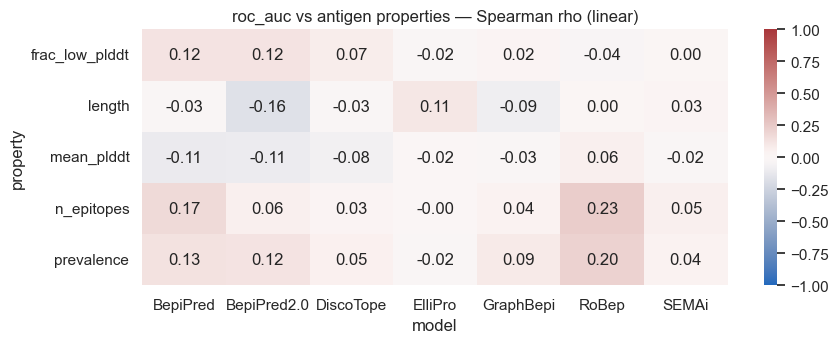

significant (p<0.05): 9 of 35

=== Spearman rho: roc_auc vs property (conformational) ===
model           BepiPred  BepiPred2.0  DiscoTope  ElliPro  GraphBepi  RoBep  SEMAi
property                                                                          
frac_low_plddt      0.07         0.10       0.15     0.07       0.20   0.35   0.17
length              0.20         0.03       0.22     0.03       0.27   0.30   0.35
mean_plddt          0.03        -0.01      -0.09    -0.08      -0.10  -0.24  -0.13
n_epitopes          0.06        -0.19       0.13    -0.18       0.12   0.23   0.13
prevalence         -0.11        -0.16      -0.16    -0.27      -0.22  -0.04  -0.23


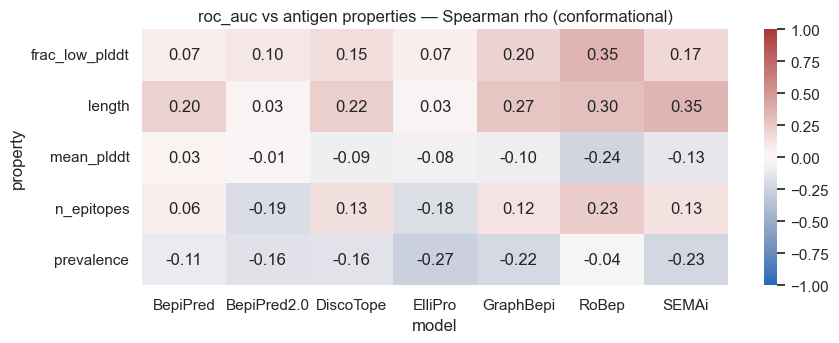

significant (p<0.05): 2 of 35


In [57]:
def spearman_table(dat, metric, typ):
    d = dat[dat.type == typ]
    rows = []
    for m in MODEL_LIST:
        dm = d[d.model == m]
        for prop in PROPS:
            x, y = dm[prop].values.astype(float), dm[metric].values.astype(float)
            mask = ~(np.isnan(x) | np.isnan(y))
            if mask.sum() < 10:
                rho, p = np.nan, np.nan
            else:
                rho, p = spearmanr(x[mask], y[mask])
            rows.append({"model": m, "property": prop, "rho": rho, "p": p, "n": int(mask.sum())})
    return pd.DataFrame(rows)

for typ in TYPES:
    sp = spearman_table(dat, PRIMARY_METRIC, typ)
    mat = sp.pivot(index="property", columns="model", values="rho")
    print(f"\n=== Spearman rho: {PRIMARY_METRIC} vs property ({typ}) ===")
    print(mat.round(2).to_string())
    plt.figure(figsize=(9, 3.6))
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1)
    plt.title(f"{PRIMARY_METRIC} vs antigen properties — Spearman rho ({typ})")
    plt.tight_layout(); plt.show()
    sig = sp[(sp.p < 0.05) & sp.rho.notna()]
    print("significant (p<0.05):", len(sig), "of", len(sp.dropna(subset=['rho'])))


### A5. Stratified performance (pLDDT band, length, prevalence)

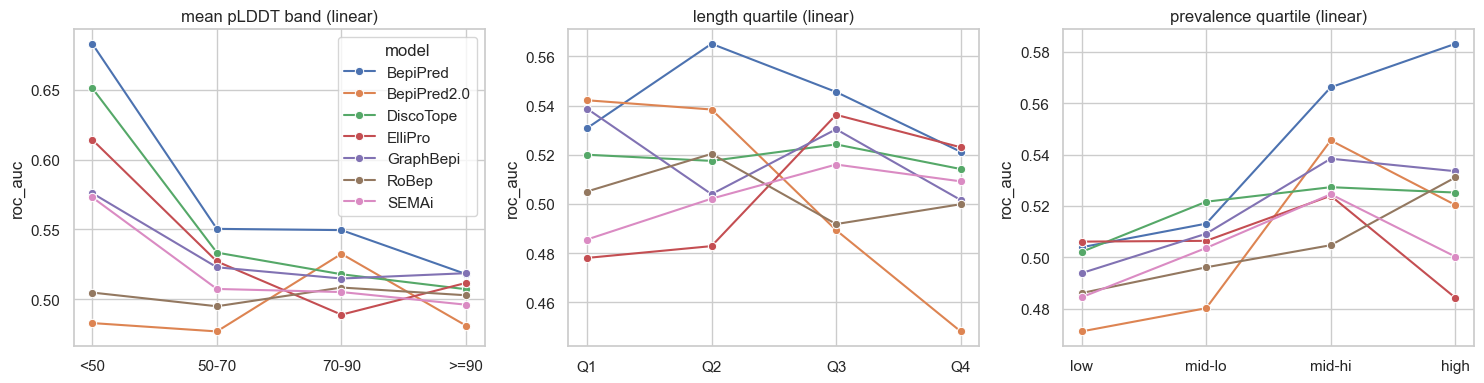

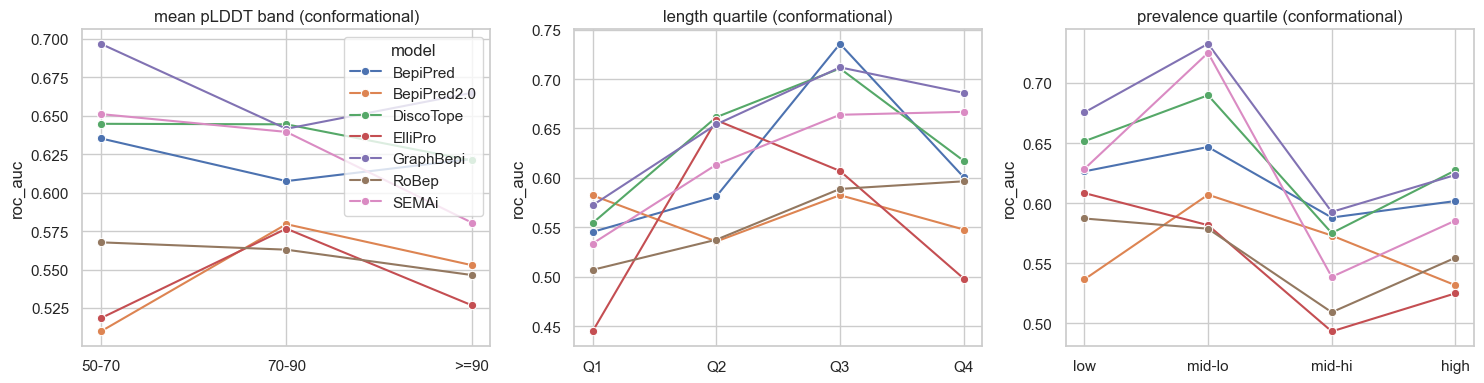

In [58]:
def banded(dat, metric, typ):
    d = dat[dat.type == typ].copy()
    d["plddt_band"] = pd.cut(d["mean_plddt"], [0, 50, 70, 90, 100],
                             labels=["<50", "50-70", "70-90", ">=90"])
    d["length_q"] = pd.qcut(d["length"], 4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop")
    d["prev_q"] = pd.qcut(d["prevalence"].rank(method="first"), 4, labels=["low", "mid-lo", "mid-hi", "high"])
    return d

for typ in TYPES:
    d = banded(dat, PRIMARY_METRIC, typ)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    for a, col, ttl in zip(ax, ["plddt_band", "length_q", "prev_q"],
                           ["mean pLDDT band", "length quartile", "prevalence quartile"]):
        tab = d.groupby([col, "model"], observed=True)[PRIMARY_METRIC].mean().reset_index()
        sns.lineplot(data=tab, x=col, y=PRIMARY_METRIC, hue="model", marker="o", ax=a, legend=(a is ax[0]))
        a.set_title(f"{ttl} ({typ})"); a.set_xlabel("")
    plt.tight_layout(); plt.show()


### A6. Multivariate — which property matters after controlling for the others

Standardised linear-regression coefficients per model (so magnitudes are comparable). This breaks
the confounding: long antigens are also lower-prevalence and have more low-pLDDT stretches, so a raw
correlation over-attributes. Read coefficients as partial effects; multicollinearity inflates their
variance, so treat small coefficients cautiously.

In [59]:
def multivariate(dat, metric, typ):
    d = dat[dat.type == typ].dropna(subset=PROPS + [metric])
    rows = []
    for m in MODEL_LIST:
        dm = d[d.model == m]
        if len(dm) < max(25, len(PROPS) + 8):
            rows.append({"model": m, "n": len(dm), "R2": np.nan, "note": "n too small"})
            continue
        X = StandardScaler().fit_transform(dm[PROPS].values)
        y = dm[metric].values
        lr = LinearRegression().fit(X, y)
        row = {"model": m, "n": len(dm), "R2": round(lr.score(X, y), 3), "note": ""}
        for prop, c in zip(PROPS, lr.coef_):
            row["b_" + prop] = round(c, 3)
        rows.append(row)
    return pd.DataFrame(rows)

for typ in TYPES:
    print(f"\n=== Standardised coefficients: {PRIMARY_METRIC} ~ properties ({typ}) ===")
    print(multivariate(dat, PRIMARY_METRIC, typ).to_string(index=False))



=== Standardised coefficients: roc_auc ~ properties (linear) ===
      model   n    R2 note  b_length  b_prevalence  b_n_epitopes  b_mean_plddt  b_frac_low_plddt
   BepiPred 311 0.045         -0.007         0.031         0.009        -0.075            -0.052
BepiPred2.0 311 0.038         -0.038         0.012        -0.004        -0.069            -0.054
  DiscoTope 311 0.017         -0.007         0.001        -0.006        -0.039            -0.021
    ElliPro 311 0.031          0.012        -0.009        -0.019        -0.062            -0.052
  GraphBepi 311 0.014         -0.014         0.004        -0.010        -0.038            -0.030
      SEMAi 311 0.010         -0.002        -0.007        -0.010        -0.044            -0.036
      RoBep 311 0.022         -0.002         0.013         0.001         0.005             0.004

=== Standardised coefficients: roc_auc ~ properties (conformational) ===
      model  n    R2 note  b_length  b_prevalence  b_n_epitopes  b_mean_plddt  b_fra

/opt/anaconda3/envs/metabolab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/metabolab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/metabolab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/metabolab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/metabolab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/metabolab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280:

### A7. Shared vs model-specific bias

For each property, is the association consistent across all models (a property of the **data/benchmark**)
or does it vary in sign/strength between models (a property of the **architecture**)? The second kind is
the finding; the first is a caveat on the dataset.

In [60]:
def shared_vs_specific(dat, metric, typ):
    sp = spearman_table(dat, metric, typ)
    out = []
    for prop, g in sp.groupby("property"):
        r = g["rho"].dropna()
        if len(r) < 2:
            continue
        same_sign = bool((r > 0).all() or (r < 0).all())
        spread = float(r.max() - r.min())
        out.append({"property": prop, "mean_rho": round(r.mean(), 3),
                    "min_rho": round(r.min(), 3), "max_rho": round(r.max(), 3),
                    "spread": round(spread, 3),
                    "verdict": "shared (data bias)" if (same_sign and spread < 0.25)
                               else "divergent (architecture)"})
    return pd.DataFrame(out)

for typ in TYPES:
    print(f"\n=== Shared vs model-specific ({typ}, {PRIMARY_METRIC}) ===")
    print(shared_vs_specific(dat, PRIMARY_METRIC, typ).to_string(index=False))



=== Shared vs model-specific (linear, roc_auc) ===
      property  mean_rho  min_rho  max_rho  spread                  verdict
frac_low_plddt     0.039   -0.039    0.122   0.161 divergent (architecture)
        length    -0.025   -0.164    0.105   0.269 divergent (architecture)
    mean_plddt    -0.044   -0.112    0.056   0.168 divergent (architecture)
    n_epitopes     0.084   -0.002    0.234   0.236 divergent (architecture)
    prevalence     0.088   -0.024    0.204   0.227 divergent (architecture)

=== Shared vs model-specific (conformational, roc_auc) ===
      property  mean_rho  min_rho  max_rho  spread                  verdict
frac_low_plddt     0.160    0.070    0.352   0.282 divergent (architecture)
        length     0.200    0.028    0.348   0.320 divergent (architecture)
    mean_plddt    -0.088   -0.241    0.034   0.276 divergent (architecture)
    n_epitopes     0.044   -0.192    0.234   0.425 divergent (architecture)
    prevalence    -0.170   -0.267   -0.045   0.222  

## Part B — biological bias

Sample sizes are small once antigens are split by biology, so this is **exploratory**: read per-group
means with their n, not the p-values alone. The conformational track (36 antigens) cannot support
subgroup testing and is descriptive only.

### B0. Fetch annotations from UniProt (run where there is internet)

BlueBEAR compute nodes are offline — run this cell on a login node or locally. It writes
`ANNOT_CSV`; the analysis below reads that file.

In [61]:
import sys
!{sys.executable} -m pip install requests

In [62]:
# RUN ONLY WHERE INTERNET IS AVAILABLE. Writes antigen_annotations.csv.
def fetch_uniprot_annotations(accessions, out_path):
    import time, io, requests
    # Columns come back in THIS order; we read by position, not by header name.
    fields = "accession,protein_families,cc_subcellular_location,xref_pfam,go_id,keyword"
    headers = {"User-Agent": "epitope-benchmark/1.0 (mailto:amanaastha.ak@gmail.com)"}
    rows, empty = [], 0
    for k, acc in enumerate(accessions):
        rec = {"uniprot": acc}
        for attempt in range(2):                       # one retry on transient failure
            try:
                url = f"https://rest.uniprot.org/uniprotkb/{acc}.tsv?fields={fields}"
                r = requests.get(url, headers=headers, timeout=30)
                if r.status_code == 200 and r.text.strip():
                    df = pd.read_csv(io.StringIO(r.text), sep="\t")
                    if len(df):
                        v = df.iloc[0]
                        rec.update({
                            "protein_family":  v.iloc[1] if df.shape[1] > 1 else "",
                            "subcellular_raw": v.iloc[2] if df.shape[1] > 2 else "",
                            "pfam":            v.iloc[3] if df.shape[1] > 3 else "",
                            "go":              v.iloc[4] if df.shape[1] > 4 else "",
                            "keywords":        v.iloc[5] if df.shape[1] > 5 else "",
                        })
                break
            except Exception as ex:
                rec["error"] = str(ex)
                time.sleep(1.0)
        if not rec.get("subcellular_raw") and not rec.get("protein_family"):
            empty += 1
        rows.append(rec)
        if (k + 1) % 25 == 0:
            print(f"  fetched {k+1}/{len(accessions)}")
        time.sleep(0.2)
    out = pd.DataFrame(rows)
    out.to_csv(out_path, index=False)
    print(f"wrote {out_path}  shape={out.shape}  |  {empty}/{len(accessions)} returned no annotation")
    return out

accessions = sorted(dat["uniprot"].unique())
annot = fetch_uniprot_annotations(accessions, ANNOT_CSV)

  fetched 25/333
  fetched 50/333
  fetched 75/333
  fetched 100/333
  fetched 125/333
  fetched 150/333
  fetched 175/333
  fetched 200/333
  fetched 225/333
  fetched 250/333
  fetched 275/333
  fetched 300/333
  fetched 325/333
wrote antigen_annotations.csv  shape=(333, 6)  |  0/333 returned no annotation


In [63]:
filled = annot.drop(columns=["uniprot"]).apply(lambda c: c.fillna("").astype(str).str.strip().ne("").mean())
print(filled.round(2))
annot["subcellular_raw"].fillna("").apply(coarse_loc).value_counts()

protein_family     0.67
subcellular_raw    0.59
pfam               0.93
go                 0.90
keywords           1.00
dtype: float64


subcellular_raw
Unknown           143
Secreted           84
Membrane           40
Outer membrane     31
Cytoplasm          24
Cell surface        6
Periplasm           5
Name: count, dtype: int64

### B1. Load annotations and derive coarse localisation / surface flag

In [64]:
def coarse_loc(text):
    t = str(text or "").lower()
    if "secreted" in t: return "Secreted"
    if "outer membrane" in t: return "Outer membrane"
    if any(w in t for w in ["cell surface", "cell wall", "fimbri", "flagell", "capsule", "pilus"]):
        return "Cell surface"
    if "periplasm" in t: return "Periplasm"
    if any(w in t for w in ["cytoplasmic membrane", "inner membrane", "cell membrane", "plasma membrane"]):
        return "Membrane"
    if "cytoplasm" in t: return "Cytoplasm"
    return "Unknown"

SURFACE = {"Secreted", "Outer membrane", "Cell surface"}
BIO = False
if ANNOT_CSV.exists():
    annot = pd.read_csv(ANNOT_CSV)
    annot["uniprot"] = annot["uniprot"].astype(str).str.strip()
    annot["localisation"] = annot.get("subcellular_raw", "").apply(coarse_loc)
    annot["surface"] = annot["localisation"].isin(SURFACE)
    annot["pfam_top"] = annot.get("pfam", "").astype(str).str.split(";").str[0].str.strip().replace("", np.nan)
    bio = dat.merge(annot[["uniprot", "localisation", "surface", "pfam_top", "protein_family"]],
                    on="uniprot", how="left")
    BIO = True
    print("annotations loaded:", annot.shape)
    print(annot["localisation"].value_counts().to_string())
else:
    print(f"[{ANNOT_CSV} not found — run B0 first. Skipping Part B.]")


annotations loaded: (333, 9)
localisation
Unknown           143
Secreted           84
Membrane           40
Outer membrane     31
Cytoplasm          24
Cell surface        6
Periplasm           5


### B2. Surface-exposed vs rest (the application-relevant cut)

Vaccine targets are surface-exposed/secreted; average performance is less relevant than performance
on those antigens specifically.

In [65]:
def surface_test(bio, metric, typ):
    d = bio[bio.type == typ].dropna(subset=[metric, "surface"])
    rows = []
    for m in MODEL_LIST:
        dm = d[d.model == m]
        a = dm[dm.surface][metric]; b = dm[~dm.surface][metric]
        if len(a) < 5 or len(b) < 5:
            rows.append({"model": m, "n_surface": len(a), "n_rest": len(b), "note": "underpowered"})
            continue
        _, p = mannwhitneyu(a, b)
        rows.append({"model": m, "n_surface": len(a), "n_rest": len(b),
                     "med_surface": round(a.median(), 3), "med_rest": round(b.median(), 3),
                     "p": round(p, 4)})
    return pd.DataFrame(rows)

if BIO:
    for typ in TYPES:
        print(f"\n=== Surface vs rest ({typ}, {PRIMARY_METRIC}) ===")
        print(surface_test(bio, PRIMARY_METRIC, typ).to_string(index=False))



=== Surface vs rest (linear, roc_auc) ===
      model  n_surface  n_rest  med_surface  med_rest      p
   BepiPred        113     198        0.595     0.523 0.0020
BepiPred2.0        113     198        0.529     0.481 0.0777
  DiscoTope        113     198        0.521     0.524 0.7866
    ElliPro        113     198        0.498     0.496 0.3974
  GraphBepi        113     198        0.524     0.511 0.5662
      SEMAi        113     198        0.506     0.491 0.2867
      RoBep        113     198        0.498     0.475 0.0324

=== Surface vs rest (conformational, roc_auc) ===
      model  n_surface  n_rest  med_surface  med_rest      p
   BepiPred         17      19        0.635     0.625 0.6573
BepiPred2.0         17      19        0.576     0.583 1.0000
  DiscoTope         17      19        0.619     0.639 1.0000
    ElliPro         17      19        0.502     0.532 0.5262
  GraphBepi         17      19        0.669     0.648 0.8991
      SEMAi         17      19        0.657     0.62

### B3. By subcellular localisation and Pfam family

Rare groups (n < `MIN_GROUP_N`) are pooled into "other"; Kruskal–Wallis across groups per model.
Report the descriptive per-group means alongside — with these n, the means matter more than p.

In [66]:
def group_test(bio, metric, typ, col):
    d = bio[bio.type == typ].dropna(subset=[metric, col]).copy()
    vc = d[col].value_counts()
    keep = vc[vc >= MIN_GROUP_N].index
    d["grp"] = np.where(d[col].isin(keep), d[col], "other")
    rows = []
    for m in MODEL_LIST:
        dm = d[d.model == m]
        groups = [g[metric].values for _, g in dm.groupby("grp") if len(g) >= 3]
        if len(groups) < 2:
            rows.append({"model": m, "n_groups": len(groups), "note": "too few groups"}); continue
        h, p = kruskal(*groups)
        rows.append({"model": m, "n_groups": len(groups), "H": round(h, 2), "p": round(p, 4)})
    desc = (d.groupby("grp")[metric].agg(mean="mean", n="size").round(3))
    return pd.DataFrame(rows), desc

if BIO:
    for col in ["localisation", "pfam_top"]:
        for typ in TYPES:
            res_tab, desc = group_test(bio, PRIMARY_METRIC, typ, col)
            print(f"\n=== {col} ({typ}, {PRIMARY_METRIC}) ===")
            print(res_tab.to_string(index=False))
            print("per-group (pooled over models):")
            print(desc.to_string())



=== localisation (linear, roc_auc) ===
      model  n_groups     H      p
   BepiPred         7 26.98 0.0001
BepiPred2.0         7 10.21 0.1160
  DiscoTope         7  7.68 0.2627
    ElliPro         7  8.65 0.1945
  GraphBepi         7  9.85 0.1310
      SEMAi         7  9.55 0.1449
      RoBep         7  9.20 0.1629
per-group (pooled over models):
                 mean    n
grp                       
Cell surface    0.568   42
Cytoplasm       0.514  154
Membrane        0.478  252
Outer membrane  0.525  210
Periplasm       0.667   28
Secreted        0.533  539
Unknown         0.503  952

=== localisation (conformational, roc_auc) ===
      model  n_groups    H      p
   BepiPred         4 0.64 0.8861
BepiPred2.0         4 7.13 0.0677
  DiscoTope         4 0.68 0.8785
    ElliPro         4 7.47 0.0584
  GraphBepi         4 1.99 0.5754
      SEMAi         4 1.00 0.8021
      RoBep         4 2.26 0.5194
per-group (pooled over models):
                 mean   n
grp                      
C

### B4. Does the surface effect survive controlling for structural covariates?

If the surface flag still predicts performance after adding mean pLDDT, length and prevalence, it is a
genuine biological effect; if its coefficient collapses, it was confounded (surface proteins differ
structurally).

In [67]:
def control_surface(bio, metric, typ):
    feats = ["surface", "mean_plddt", "length", "prevalence"]
    d = bio[bio.type == typ].dropna(subset=[metric] + feats).copy()
    d["surface"] = d["surface"].astype(int)
    rows = []
    for m in MODEL_LIST:
        dm = d[d.model == m]
        if len(dm) < max(25, len(feats) + 8):
            rows.append({"model": m, "n": len(dm), "note": "n too small"}); continue
        X = StandardScaler().fit_transform(dm[feats].values)
        y = dm[metric].values
        lr = LinearRegression().fit(X, y)
        b = dict(zip(feats, lr.coef_))
        # univariate surface effect for comparison
        a1 = dm[dm.surface == 1][metric]; a0 = dm[dm.surface == 0][metric]
        uni = (a1.mean() - a0.mean()) if len(a1) and len(a0) else np.nan
        rows.append({"model": m, "n": len(dm), "R2": round(lr.score(X, y), 3),
                     "b_surface_adj": round(b["surface"], 3),
                     "uni_surface_diff": round(uni, 3) if uni == uni else np.nan})
    return pd.DataFrame(rows)

if BIO:
    for typ in TYPES:
        print(f"\n=== Surface effect, adjusted vs unadjusted ({typ}, {PRIMARY_METRIC}) ===")
        print(control_surface(bio, PRIMARY_METRIC, typ).to_string(index=False))



=== Surface effect, adjusted vs unadjusted (linear, roc_auc) ===
      model   n    R2  b_surface_adj  uni_surface_diff
   BepiPred 311 0.056          0.028             0.082
BepiPred2.0 311 0.042          0.019             0.047
  DiscoTope 311 0.016          0.002             0.007
    ElliPro 311 0.029          0.018             0.017
  GraphBepi 311 0.010          0.005             0.010
      SEMAi 311 0.013          0.016             0.021
      RoBep 311 0.026          0.007             0.022

=== Surface effect, adjusted vs unadjusted (conformational, roc_auc) ===
      model  n    R2  b_surface_adj  uni_surface_diff
   BepiPred 36 0.072         -0.011            -0.006
BepiPred2.0 36 0.071          0.002             0.003
  DiscoTope 36 0.029         -0.007            -0.004
    ElliPro 36 0.089         -0.023            -0.040
  GraphBepi 36 0.083         -0.005             0.006
      SEMAi 36 0.135          0.002             0.027
      RoBep 36 0.066          0.005       

/opt/anaconda3/envs/metabolab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/metabolab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/metabolab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/metabolab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/metabolab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/metabolab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280:

## Summary & reporting notes

- **Part A is the defensible core.** Report the shared-vs-model-specific table and the multivariate
  coefficients; the pLDDT stratification here is the analysis behind methods 4.3.6.
- **PR-AUC vs prevalence** is partly mechanical — say so once and lead with ROC-AUC / matched-recall
  for the prevalence question.
- **Part B is exploratory** given subgroup n. Present the surface-exposed cut and any Pfam/localisation
  effect that survives the structural control (B4) as the reportable pieces; state the group sizes.
- **Conformational** subgroup results are descriptive only (36 antigens).
- **Extensibility:** add a model (one line in `MODELS`), or viral groups (extend `ORGS`); everything
  recomputes. Set `PRIMARY_METRIC` to `roc_auc` / `pr_auc` to rerun any section on another unit.